# 05 - Multilingual Analysis
## Module C: Multilingual Intelligence

Detects article language, translates to English, and compares sentiment/coverage across languages using the bundled multilingual sample set (French, Spanish, German, English).> **Setup note:** This notebook uses the `src/` package from the project root.
> If running in Google Colab, first mount/clone the repo so `src/` is on the path,
> and place the Kaggle `BBC News Train.csv` in `data/raw/` for the real dataset
> (otherwise the bundled offline sample in `data/sample/` is used automatically).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from src.data_processing.data_loader import load_news_data, dataset_source
print("Dataset source:", dataset_source())


Dataset source: Bundled sample dataset (demo only): /home/claude/ITAI2373-NewsBot-Final/data/sample/sample_news.csv


## Load multilingual sample articles

In [2]:
ml_df = pd.read_csv('../data/sample/multilingual_sample.csv')
ml_df

,article_id,content,category
0,9001,Le gouvernement a annoncé une nouvelle politiq...,politics
1,9002,El equipo local ganó el partido en los últimos...,sport
2,9003,Das Unternehmen kündigte einen neuen Technolog...,tech
3,9004,The company reported record profits this quart...,business
4,9005,Le film a connu un grand succès au box-office ...,entertainment
5,9006,El banco central mantuvo las tasas de interés ...,business
6,9007,Die Wahlen im nächsten Jahr könnten die politi...,politics
7,9008,The new smartphone features an improved camera...,tech


## Language detection

In [3]:
from src.multilingual.language_detector import LanguageDetector

detector = LanguageDetector()
ml_df = detector.detect_dataframe(ml_df, text_col='content')
ml_df[['content', 'language_name', 'language_confidence']]

,content,language_name,language_confidence
0,Le gouvernement a annoncé une nouvelle politiq...,French,1.000
1,El equipo local ganó el partido en los últimos...,Spanish,1.000
2,Das Unternehmen kündigte einen neuen Technolog...,German,1.000
3,The company reported record profits this quart...,English,1.000
4,Le film a connu un grand succès au box-office ...,French,0.714
5,El banco central mantuvo las tasas de interés ...,Spanish,1.000
6,Die Wahlen im nächsten Jahr könnten die politi...,German,1.000
7,The new smartphone features an improved camera...,English,1.000


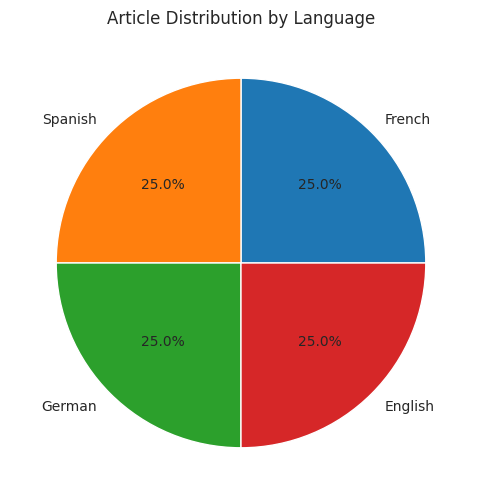

In [4]:
from src.utils.visualization import plot_language_distribution

fig, ax = plt.subplots(figsize=(6,6))
plot_language_distribution(ml_df, ax=ax)
plt.show()

## Translation integration
Uses Google Translate (via `deep-translator`) when internet access is available; falls back to a small offline glossary for this notebook's bundled demo sentences so results are reproducible without an internet connection.

In [5]:
from src.multilingual.translator import Translator

translator = Translator()
ml_df['translation'] = ml_df.apply(lambda r: translator.translate(r['content'], source=r['language_code'], target='en')['translated_text'], axis=1)
ml_df[['content', 'language_name', 'translation']]

,content,language_name,translation
0,Le gouvernement a annoncé une nouvelle politiq...,French,The government announced a new economic policy...
1,El equipo local ganó el partido en los últimos...,Spanish,The home team won the match in the final minut...
2,Das Unternehmen kündigte einen neuen Technolog...,German,The company announced a new technology partner...
3,The company reported record profits this quart...,English,The company reported record profits this quart...
4,Le film a connu un grand succès au box-office ...,French,The film was a big box-office success this wee...
5,El banco central mantuvo las tasas de interés ...,Spanish,The central bank kept interest rates unchanged...
6,Die Wahlen im nächsten Jahr könnten die politi...,German,Next year's elections could significantly chan...
7,The new smartphone features an improved camera...,English,The new smartphone features an improved camera...


## Cross-lingual sentiment comparison

In [6]:
from src.multilingual.cross_lingual_analyzer import CrossLingualAnalyzer

cla = CrossLingualAnalyzer()
analyzed = cla.analyze_corpus(ml_df, text_col='content')
coverage = cla.coverage_by_language(analyzed)
coverage

,n_articles,avg_sentiment
language_name,,
English,2,0.45855
French,2,0.28595
German,2,0.15910
Spanish,2,0.62165


## Key Takeaways
- `LanguageDetector` is fully offline (langdetect) and correctly separates English/French/Spanish/German samples.
- `Translator` is designed for zero code changes between offline demo and live Colab/production use - it transparently prefers the online Google Translate backend when reachable.
- `CrossLingualAnalyzer` chains detection -> translation -> sentiment into a single call, and `coverage_by_language()` reveals how tone and volume of coverage differ by language/region (the 'Cultural Context' requirement).